# EURUSD Daily MTOFX Linear Regression Framework

This notebook groups EURUSD daily features into economically coherent modules and tests them with simple, interpretable OLS regressions. The design is deliberately linear: every group should correspond to a macro or technical story that can be checked through coefficient signs, p-values, group F-tests, rolling R^2, and rolling coefficient stability.

Target convention used below: predict a forward EURUSD return such as `target_ret_1d_fwd`. If that target is not already in the data, the notebook can create it from a close-price column.


## Proposed Feature Groups And Rationale

The groups below are disjoint so attribution is clean when comparing single-group and combined OLS specifications. The MTOFX axes are price action, flows, cost of capital, risk/confidence, and cycles.

| Group | Features | Rationale |
|---|---|---|
| `price_action` | `ret_1d`, `bb_z_20`, `breakout_20`, `drawdown_20`, `range_pct` | Immediate market behavior: short-term pressure, extension versus recent bands, breakout state, drawdown pressure, and daily range. In a linear model this is the closest proxy for current price imbalance. |
| `momentum_trend` | `ret_5d`, `ret_20d`, all SMA/EMA/distance-to-SMA fields, `rsi_14`, `macd`, `macd_signal`, `macd_hist` | Trend persistence versus mean reversion. Distance-to-average features are generally more stationary than raw SMA/EMA levels; raw averages are included because they are in the supplied feature set, but monitor them for collinearity and instability in return regressions. |
| `realized_volatility` | `vol_20d`, `vol_63d`, `atr_14`, `atr_pct_14` | Realized uncertainty and local trading range. Volatility can change expected return through risk premia, stop-loss pressure, and regime-dependent trend reliability. |
| `macro_rates` | `us_10y_nominal`, `us_2y_nominal`, `us_10y_real`, `fed_funds`, `us_curve_10y2y`, `eu_10y_nominal`, `eu_2y_nominal`, `eu_10y_real`, `ecb_deposit_rate`, `ecb_main_refi_rate`, `eu_curve_10y2y`, `eu_hicp_yoy` | Cost-of-capital block. US and EUR nominal/real-rate proxies, front-end policy rates, and curve shape represent cross-currency carry, growth/inflation expectations, and central-bank reaction-function pressure. |
| `risk_confidence` | `vix`, `vix_low_regime`, `vix_mid_regime`, `vix_high_regime`, `eu_ciss`, `eu_ciss_low_regime`, `eu_ciss_mid_regime`, `eu_ciss_high_regime` | Risk/confidence block. VIX proxies global risk appetite and USD safe-haven pressure; ECB CISS proxies euro-area systemic stress. Regime dummies allow the same signal to behave differently across calm, normal, and stressed markets. |
| `positioning_flows` | `cot_euro_net_noncommercial`, `cot_euro_net_4w_change`, `cot_euro_net_z_156w`, `cot_euro_net_4w_ma` | Flows and positioning block. COT captures speculative EUR futures exposure, recent change, and crowding versus a long window. It is slow-moving, so it is often more useful for medium-horizon bias than next-day timing. |
| `cycles_regime` | `kitchin_cycle_sin`, `kitchin_cycle_cos`, `juglar_cycle_sin`, `juglar_cycle_cos` | Cycle priors. Sine/cosine pairs encode low-frequency macro inventory/business-cycle timing without imposing discontinuities. These are context variables, not standalone alpha. |

Research guidance: for daily EURUSD returns, expect low absolute R^2. The question is not whether a group explains most of the return variance, but whether it adds stable incremental explanatory power, improves AIC, and has economically coherent signs across rolling windows.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Mapping, Sequence

import numpy as np
import pandas as pd
try:
    import statsmodels.api as sm
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "statsmodels is required for OLS. Install project requirements or run `%pip install statsmodels`."
    ) from exc

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")


In [2]:
FEATURES = [
    "ret_1d", "ret_5d", "ret_20d", "vol_20d", "vol_63d", "sma_10", "ema_10",
    "dist_sma_10", "sma_20", "ema_20", "dist_sma_20", "sma_50", "ema_50",
    "dist_sma_50", "sma_100", "ema_100", "dist_sma_100", "sma_200",
    "ema_200", "dist_sma_200", "rsi_14", "macd", "macd_signal", "macd_hist",
    "bb_z_20", "atr_14", "atr_pct_14", "breakout_20", "drawdown_20",
    "range_pct", "us_10y_nominal", "us_2y_nominal", "us_10y_real", "vix",
    "fed_funds", "eu_10y_nominal", "eu_2y_nominal", "eu_10y_real",
    "ecb_deposit_rate", "ecb_main_refi_rate", "eu_curve_10y2y", "eu_ciss",
    "eu_ciss_low_regime", "eu_ciss_mid_regime", "eu_ciss_high_regime", "eu_hicp_yoy",
    "cot_euro_net_noncommercial", "cot_euro_net_4w_change", "cot_euro_net_z_156w",
    "us_curve_10y2y", "vix_low_regime", "vix_mid_regime", "vix_high_regime", "cot_euro_net_4w_ma",
    "kitchin_cycle_sin", "kitchin_cycle_cos", "juglar_cycle_sin", "juglar_cycle_cos",
]

RAW_MA_LEVELS = [
    "sma_10", "ema_10", "sma_20", "ema_20", "sma_50", "ema_50",
    "sma_100", "ema_100", "sma_200", "ema_200",
]


In [3]:
@dataclass(frozen=True)
class FeatureGroup:
    key: str
    label: str
    features: tuple[str, ...]
    mtofx_axis: str
    rationale: str


class FeatureGroupRegistry:
    """Registry for named, economically coherent feature groups."""

    def __init__(self, groups: Sequence[FeatureGroup]):
        self.groups = {group.key: group for group in groups}
        if len(self.groups) != len(groups):
            raise ValueError("Duplicate group key found.")

    @property
    def keys(self) -> list[str]:
        return list(self.groups.keys())

    def __getitem__(self, key: str) -> FeatureGroup:
        return self.groups[key]

    def features(self, group_keys: Sequence[str], *, exclude: Sequence[str] | None = None) -> list[str]:
        exclude_set = set(exclude or [])
        selected: list[str] = []
        for key in group_keys:
            if key not in self.groups:
                raise KeyError(f"Unknown feature group: {key}")
            for feature in self.groups[key].features:
                if feature not in exclude_set and feature not in selected:
                    selected.append(feature)
        return selected

    def feature_to_group(self) -> dict[str, str]:
        mapping: dict[str, str] = {}
        for group in self.groups.values():
            for feature in group.features:
                mapping[feature] = group.key
        return mapping

    def summary(self) -> pd.DataFrame:
        return pd.DataFrame(
            [
                {
                    "group": group.key,
                    "label": group.label,
                    "mtofx_axis": group.mtofx_axis,
                    "n_features": len(group.features),
                    "features": ", ".join(group.features),
                    "rationale": group.rationale,
                }
                for group in self.groups.values()
            ]
        )

    def validate(self, columns: Sequence[str], *, strict: bool = False) -> pd.DataFrame:
        available = set(columns)
        rows = []
        for group in self.groups.values():
            missing = [feature for feature in group.features if feature not in available]
            rows.append(
                {
                    "group": group.key,
                    "n_features": len(group.features),
                    "n_missing": len(missing),
                    "missing_features": ", ".join(missing),
                }
            )
        out = pd.DataFrame(rows)
        if strict and out["n_missing"].sum() > 0:
            raise ValueError("Some grouped features are missing from the data.")
        return out


FEATURE_GROUPS = [
    FeatureGroup(
        key="price_action",
        label="Pure Price Action",
        mtofx_axis="Price action / market imbalance",
        features=("ret_1d", "bb_z_20", "breakout_20", "drawdown_20", "range_pct"),
        rationale="Immediate pressure, extension, breakout, drawdown, and range state in EURUSD itself.",
    ),
    FeatureGroup(
        key="momentum_trend",
        label="Momentum And Trend",
        mtofx_axis="Price action / trend persistence",
        features=(
            "ret_5d", "ret_20d", "sma_10", "ema_10", "dist_sma_10", "sma_20", "ema_20", "dist_sma_20",
            "sma_50", "ema_50", "dist_sma_50", "sma_100", "ema_100", "dist_sma_100", "sma_200", "ema_200",
            "dist_sma_200", "rsi_14", "macd", "macd_signal", "macd_hist",
        ),
        rationale="Trend, mean-reversion distance, and oscillator state across short, medium, and long windows.",
    ),
    FeatureGroup(
        key="realized_volatility",
        label="Realized Volatility",
        mtofx_axis="Volatility / risk premia",
        features=("vol_20d", "vol_63d", "atr_14", "atr_pct_14"),
        rationale="Realized variance and range pressure; useful for volatility-conditioned trend and risk-premium behavior.",
    ),
    FeatureGroup(
        key="macro_rates",
        label="Macro Rates And Curve",
        mtofx_axis="Cost of capital",
        features=(
            "us_10y_nominal", "us_2y_nominal", "us_10y_real", "fed_funds", "us_curve_10y2y",
            "eu_10y_nominal", "eu_2y_nominal", "eu_10y_real", "ecb_deposit_rate", "ecb_main_refi_rate",
            "eu_curve_10y2y", "eu_hicp_yoy",
        ),
        rationale="USD and EUR-side carry, real-rate support, central-bank policy stance, and curve shape.",
    ),
    FeatureGroup(
        key="risk_confidence",
        label="Risk And Confidence",
        mtofx_axis="Risk appetite / confidence",
        features=(
            "vix", "vix_low_regime", "vix_mid_regime", "vix_high_regime",
            "eu_ciss", "eu_ciss_low_regime", "eu_ciss_mid_regime", "eu_ciss_high_regime",
        ),
        rationale="US/global volatility and euro-area systemic stress regimes linked to USD and EUR confidence.",
    ),
    FeatureGroup(
        key="positioning_flows",
        label="Positioning And Flows",
        mtofx_axis="Flows / speculative positioning",
        features=("cot_euro_net_noncommercial", "cot_euro_net_4w_change", "cot_euro_net_z_156w", "cot_euro_net_4w_ma"),
        rationale="COT speculative EUR exposure, exposure change, slow-moving average, and crowding z-score.",
    ),
    FeatureGroup(
        key="cycles_regime",
        label="Cycles And Regime",
        mtofx_axis="Cycle context",
        features=("kitchin_cycle_sin", "kitchin_cycle_cos", "juglar_cycle_sin", "juglar_cycle_cos"),
        rationale="Low-frequency inventory/business-cycle timing encoded continuously with sine/cosine pairs.",
    ),
]

registry = FeatureGroupRegistry(FEATURE_GROUPS)
registry.summary()


,group,label,mtofx_axis,n_features,features,rationale
0,price_action,Pure Price Action,Price action / market imbalance,5,"ret_1d, bb_z_20, breakout_20, drawdown_20, ran...","Immediate pressure, extension, breakout, drawd..."
1,momentum_trend,Momentum And Trend,Price action / trend persistence,21,"ret_5d, ret_20d, sma_10, ema_10, dist_sma_10, ...","Trend, mean-reversion distance, and oscillator..."
2,realized_volatility,Realized Volatility,Volatility / risk premia,4,"vol_20d, vol_63d, atr_14, atr_pct_14",Realized variance and range pressure; useful f...
3,macro_rates,Macro Rates And Curve,Cost of capital,12,"us_10y_nominal, us_2y_nominal, us_10y_real, fe...","USD and EUR-side carry, real-rate support, cen..."
4,risk_confidence,Risk And Confidence,Risk appetite / confidence,8,"vix, vix_low_regime, vix_mid_regime, vix_high_...",US/global volatility and euro-area systemic st...
5,positioning_flows,Positioning And Flows,Flows / speculative positioning,4,"cot_euro_net_noncommercial, cot_euro_net_4w_ch...","COT speculative EUR exposure, exposure change,..."
6,cycles_regime,Cycles And Regime,Cycle context,4,"kitchin_cycle_sin, kitchin_cycle_cos, juglar_c...",Low-frequency inventory/business-cycle timing ...


## Data Loading

Set `REFRESH_DATA = True` to pull the daily EURUSD feature table from MetaTrader5, FRED, and COT reports. The pull writes a CSV to `FEATURE_TABLE_PATH`, then the existing loader reads that table. Supported load formats are CSV, Parquet, Pickle, and Feather. If `DATA_PATH = None`, the loader will use an existing in-memory `df` if one is already defined in the notebook session.

The cleanest target for this framework is a forward return such as `target_ret_1d_fwd`. Avoid using contemporaneous `ret_1d` as the target while also using it as a predictor.


In [4]:
from metalib.mtofx_daily_data import build_eurusd_mtofx_daily_features

PROJECT_ROOT = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "setup.py").exists()), Path.cwd())
FEATURE_TABLE_PATH = PROJECT_ROOT / "metalib" / "data" / "eurusd" / "eurusd_mtofx_daily_features.csv"

REFRESH_DATA = True
FRED_API_KEY = "d32f52d45fc621a2848f31540442b8cd"
DATA_START = "2005-01-01"
DATA_END: str | None = None

if REFRESH_DATA:
    df = build_eurusd_mtofx_daily_features(
        symbol="EURUSD",
        start=DATA_START,
        end=DATA_END,
        fred_api_key=FRED_API_KEY,
        output_path=FEATURE_TABLE_PATH,
    )

DATA_PATH: str | Path | None = FEATURE_TABLE_PATH if FEATURE_TABLE_PATH.exists() else None
DATE_COL = "date"
TARGET_COL = "target_ret_1d_fwd"
PRICE_COL: str | None = None

PRICE_COL_CANDIDATES = ["close", "Close", "CLOSE", "eurusd_close", "EURUSD", "price", "last"]


def load_research_data(path: str | Path | None = None, *, date_col: str | None = DATE_COL) -> pd.DataFrame:
    if path is None:
        if "df" in globals() and isinstance(globals()["df"], pd.DataFrame):
            data = globals()["df"].copy()
        else:
            raise FileNotFoundError("Set DATA_PATH or define a DataFrame named df before running this cell.")
    else:
        path = Path(path)
        suffix = path.suffix.lower()
        if suffix == ".csv":
            data = pd.read_csv(path)
        elif suffix in {".parquet", ".pq"}:
            data = pd.read_parquet(path)
        elif suffix in {".pkl", ".pickle"}:
            data = pd.read_pickle(path)
        elif suffix == ".feather":
            data = pd.read_feather(path)
        else:
            raise ValueError(f"Unsupported data format: {suffix}")

    if date_col and date_col in data.columns:
        data[date_col] = pd.to_datetime(data[date_col])
        data = data.sort_values(date_col).set_index(date_col)
    elif not isinstance(data.index, pd.DatetimeIndex):
        data = data.sort_index()
    return data


def infer_price_col(data: pd.DataFrame, price_col: str | None = None) -> str:
    if price_col and price_col in data.columns:
        return price_col
    for candidate in PRICE_COL_CANDIDATES:
        if candidate in data.columns:
            return candidate
    raise KeyError("No price column found. Set PRICE_COL or create TARGET_COL before fitting regressions.")


def add_forward_return_target(
    data: pd.DataFrame,
    *,
    target_col: str = TARGET_COL,
    price_col: str | None = PRICE_COL,
    periods: int = 1,
    log_return: bool = True,
) -> pd.DataFrame:
    out = data.copy()
    px_col = infer_price_col(out, price_col)
    px = pd.to_numeric(out[px_col], errors="coerce")
    if log_return:
        out[target_col] = np.log(px.shift(-periods) / px)
    else:
        out[target_col] = px.pct_change(periods).shift(-periods)
    return out


# Example:
# data = load_research_data(DATA_PATH, date_col=DATE_COL)
# if TARGET_COL not in data.columns:
#     data = add_forward_return_target(data, target_col=TARGET_COL, price_col=PRICE_COL, periods=1)
# registry.validate(data.columns)


Selected: legacy_fut
Downloaded single year data from: 2005
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2006
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2007
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2008
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2009
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2010
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2011
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2012
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2013
Stored the file annual.txt in the wo

## OLS Framework

Predictors are standardized by default. This makes coefficient magnitudes comparable across groups and stabilizes regressions when features have different units. The target is not standardized, so coefficients are interpreted as target-return change per one standard deviation move in the feature.


In [5]:
@dataclass
class OLSRun:
    name: str
    groups: tuple[str, ...]
    features: tuple[str, ...]
    result: object
    model_frame: pd.DataFrame


class LinearFeatureModeler:
    def __init__(
        self,
        data: pd.DataFrame,
        target_col: str,
        registry: FeatureGroupRegistry,
        *,
        standardize: bool = True,
        cov_type: str = "HAC",
        cov_kwds: Mapping[str, int] | None = None,
    ):
        self.data = data.copy().sort_index()
        self.target_col = target_col
        self.registry = registry
        self.standardize = standardize
        self.cov_type = cov_type
        self.cov_kwds = dict(cov_kwds or {"maxlags": 5})
        if self.target_col not in self.data.columns:
            raise KeyError(f"Target column not found: {self.target_col}")

    def select_features(
        self,
        groups: Sequence[str] | None = None,
        *,
        features: Sequence[str] | None = None,
        exclude: Sequence[str] | None = None,
    ) -> list[str]:
        selected = []
        if groups:
            selected.extend(self.registry.features(groups, exclude=exclude))
        exclude_set = set(exclude or [])
        for feature in features or []:
            if feature not in selected and feature not in exclude_set:
                selected.append(feature)
        return selected

    def _model_frame(self, features: Sequence[str]) -> pd.DataFrame:
        missing = [col for col in [self.target_col, *features] if col not in self.data.columns]
        if missing:
            raise KeyError(f"Missing columns in data: {missing}")
        frame = self.data[[self.target_col, *features]].copy()
        for col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
        return frame.replace([np.inf, -np.inf], np.nan).dropna()

    def _prepare_xy(self, frame: pd.DataFrame, features: Sequence[str]) -> tuple[pd.Series, pd.DataFrame]:
        y = frame[self.target_col].astype(float)
        x = frame[list(features)].astype(float)
        if self.standardize:
            means = x.mean(axis=0)
            stds = x.std(axis=0, ddof=0).replace(0.0, np.nan)
            x = (x - means) / stds
            x = x.dropna(axis=1, how="all")
            dropped = sorted(set(features) - set(x.columns))
            if dropped:
                print(f"Dropped zero-variance features: {dropped}")
        x = sm.add_constant(x, has_constant="add")
        return y.loc[x.index], x

    def fit(
        self,
        name: str,
        groups: Sequence[str] | None = None,
        *,
        features: Sequence[str] | None = None,
        exclude: Sequence[str] | None = None,
    ) -> OLSRun:
        selected = self.select_features(groups, features=features, exclude=exclude)
        if not selected:
            raise ValueError("No features selected.")
        frame = self._model_frame(selected)
        y, x = self._prepare_xy(frame, selected)
        result = sm.OLS(y, x).fit(cov_type=self.cov_type, cov_kwds=self.cov_kwds)
        kept_features = tuple(feature for feature in selected if feature in x.columns)
        return OLSRun(name=name, groups=tuple(groups or ()), features=kept_features, result=result, model_frame=frame)

    def run_specs(self, specs: Mapping[str, Mapping]) -> dict[str, OLSRun]:
        runs = {}
        for name, spec in specs.items():
            runs[name] = self.fit(
                name,
                spec.get("groups"),
                features=spec.get("features"),
                exclude=spec.get("exclude"),
            )
        return runs

    def compare_runs(self, runs: Mapping[str, OLSRun]) -> pd.DataFrame:
        rows = []
        for name, run in runs.items():
            pvalues = run.result.pvalues.drop(labels="const", errors="ignore")
            rows.append(
                {
                    "model": name,
                    "groups": "+".join(run.groups) if run.groups else "custom",
                    "nobs": int(run.result.nobs),
                    "n_features": len(run.features),
                    "r2": run.result.rsquared,
                    "adj_r2": run.result.rsquared_adj,
                    "aic": run.result.aic,
                    "bic": run.result.bic,
                    "max_pvalue": pvalues.max() if len(pvalues) else np.nan,
                    "share_p_lt_10pct": (pvalues < 0.10).mean() if len(pvalues) else np.nan,
                    "share_p_lt_05pct": (pvalues < 0.05).mean() if len(pvalues) else np.nan,
                }
            )
        return pd.DataFrame(rows).sort_values(["adj_r2", "aic"], ascending=[False, True]).reset_index(drop=True)

    def coefficient_table(self, run: OLSRun) -> pd.DataFrame:
        conf = run.result.conf_int()
        out = pd.DataFrame(
            {
                "coef": run.result.params,
                "std_err": run.result.bse,
                "t_stat": run.result.tvalues,
                "p_value": run.result.pvalues,
                "ci_low": conf[0],
                "ci_high": conf[1],
            }
        )
        group_map = self.registry.feature_to_group()
        out["group"] = [group_map.get(idx, "constant") for idx in out.index]
        return out.reset_index(names="feature").sort_values("p_value")

    def group_f_tests(self, run: OLSRun) -> pd.DataFrame:
        exog_names = list(run.result.model.exog_names)
        rows = []
        for key in self.registry.keys:
            group_features = [f for f in self.registry[key].features if f in exog_names]
            if not group_features:
                continue
            r_matrix = np.zeros((len(group_features), len(exog_names)))
            for i, feature in enumerate(group_features):
                r_matrix[i, exog_names.index(feature)] = 1.0
            test = run.result.f_test(r_matrix)
            rows.append(
                {
                    "group": key,
                    "n_features": len(group_features),
                    "f_stat": float(np.asarray(test.fvalue).ravel()[0]),
                    "p_value": float(np.asarray(test.pvalue).ravel()[0]),
                }
            )
        return pd.DataFrame(rows).sort_values("p_value")

    def incremental_group_contribution(
        self,
        base_groups: Sequence[str],
        candidate_groups: Sequence[str],
        *,
        exclude: Sequence[str] | None = None,
    ) -> pd.DataFrame:
        base = self.fit("base", base_groups, exclude=exclude)
        rows = []
        for group in candidate_groups:
            expanded_groups = list(dict.fromkeys([*base_groups, group]))
            expanded = self.fit(f"base_plus_{group}", expanded_groups, exclude=exclude)
            rows.append(
                {
                    "added_group": group,
                    "base_adj_r2": base.result.rsquared_adj,
                    "expanded_adj_r2": expanded.result.rsquared_adj,
                    "delta_adj_r2": expanded.result.rsquared_adj - base.result.rsquared_adj,
                    "base_aic": base.result.aic,
                    "expanded_aic": expanded.result.aic,
                    "delta_aic": expanded.result.aic - base.result.aic,
                    "expanded_n_features": len(expanded.features),
                }
            )
        return pd.DataFrame(rows).sort_values("delta_adj_r2", ascending=False)

    def rolling_fit(
        self,
        name: str,
        groups: Sequence[str] | None = None,
        *,
        features: Sequence[str] | None = None,
        exclude: Sequence[str] | None = None,
        window: int = 252,
        step: int = 21,
        min_obs: int | None = None,
    ) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        selected = self.select_features(groups, features=features, exclude=exclude)
        frame = self._model_frame(selected)
        min_obs = min_obs or max(80, len(selected) + 20)
        metrics, params, pvalues = [], [], []
        for end in range(window, len(frame) + 1, step):
            chunk = frame.iloc[end - window:end]
            if len(chunk) < min_obs:
                continue
            y, x = self._prepare_xy(chunk, selected)
            if len(y) < min_obs:
                continue
            res = sm.OLS(y, x).fit(cov_type=self.cov_type, cov_kwds=self.cov_kwds)
            asof = chunk.index[-1]
            metrics.append({"date": asof, "model": name, "r2": res.rsquared, "adj_r2": res.rsquared_adj, "nobs": int(res.nobs)})
            params.append(pd.Series(res.params, name=asof))
            pvalues.append(pd.Series(res.pvalues, name=asof))
        metrics_df = pd.DataFrame(metrics).set_index("date") if metrics else pd.DataFrame()
        params_df = pd.DataFrame(params) if params else pd.DataFrame()
        pvalues_df = pd.DataFrame(pvalues) if pvalues else pd.DataFrame()
        return metrics_df, params_df, pvalues_df


## Model Specifications

These specifications run every group alone, then economically meaningful combinations. The `full_mtofx_stationary` spec excludes raw moving-average levels because they are often collinear and non-stationary in return regressions; distance-to-average features remain.


In [6]:
def build_default_specs(registry: FeatureGroupRegistry) -> dict[str, dict]:
    specs: dict[str, dict] = {group: {"groups": [group]} for group in registry.keys}
    specs.update(
        {
            "technical_core": {"groups": ["price_action", "momentum_trend", "realized_volatility"]},
            "macro_core": {"groups": ["macro_rates", "risk_confidence", "positioning_flows", "cycles_regime"]},
            "rates_risk_flows": {"groups": ["macro_rates", "risk_confidence", "positioning_flows"]},
            "full_mtofx": {"groups": registry.keys},
            "full_mtofx_stationary": {"groups": registry.keys, "exclude": RAW_MA_LEVELS},
        }
    )
    return specs


REGRESSION_SPECS = build_default_specs(registry)
REGRESSION_SPECS


{'price_action': {'groups': ['price_action']},
 'momentum_trend': {'groups': ['momentum_trend']},
 'realized_volatility': {'groups': ['realized_volatility']},
 'macro_rates': {'groups': ['macro_rates']},
 'risk_confidence': {'groups': ['risk_confidence']},
 'positioning_flows': {'groups': ['positioning_flows']},
 'cycles_regime': {'groups': ['cycles_regime']},
 'technical_core': {'groups': ['price_action',
   'momentum_trend',
   'realized_volatility']},
 'macro_core': {'groups': ['macro_rates',
   'risk_confidence',
   'positioning_flows',
   'cycles_regime']},
 'rates_risk_flows': {'groups': ['macro_rates',
   'risk_confidence',
   'positioning_flows']},
 'full_mtofx': {'groups': ['price_action',
   'momentum_trend',
   'realized_volatility',
   'macro_rates',
   'risk_confidence',
   'positioning_flows',
   'cycles_regime']},
 'full_mtofx_stationary': {'groups': ['price_action',
   'momentum_trend',
   'realized_volatility',
   'macro_rates',
   'risk_confidence',
   'positioning_fl

## Run Regressions

After setting `DATA_PATH` or defining `df`, run the following cells. The comparison table ranks models by adjusted R^2 first, then AIC. For daily FX, prioritize incremental adjusted R^2, lower AIC, stable signs, and sensible group F-tests over headline in-sample R^2.


In [10]:
data.columns

Index(['symbol', 'open', 'high', 'low', 'close', 'tick_volume', 'real_volume', 'spread', 'ret_1d', 'ret_5d', 'ret_20d', 'vol_20d', 'vol_63d', 'sma_10',
       'ema_10', 'dist_sma_10', 'sma_20', 'ema_20', 'dist_sma_20', 'sma_50', 'ema_50', 'dist_sma_50', 'sma_100', 'ema_100', 'dist_sma_100', 'sma_200',
       'ema_200', 'dist_sma_200', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_z_20', 'atr_14', 'atr_pct_14', 'breakout_20', 'drawdown_20', 'range_pct',
       'us_10y_nominal', 'us_2y_nominal', 'us_10y_real', 'vix', 'fed_funds', 'eu_10y_nominal', 'eu_2y_nominal', 'eu_10y_real', 'ecb_deposit_rate',
       'ecb_main_refi_rate', 'eu_curve_10y2y', 'eu_ciss', 'eu_ciss_low_regime', 'eu_ciss_mid_regime', 'eu_ciss_high_regime', 'eu_hicp_yoy',
       'cot_euro_net_noncommercial', 'cot_euro_net_4w_change', 'cot_euro_net_z_156w', 'us_curve_10y2y', 'vix_low_regime', 'vix_mid_regime', 'vix_high_regime',
       'cot_euro_net_4w_ma', 'kitchin_cycle_sin', 'kitchin_cycle_cos', 'juglar_cycle_sin', 'j

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

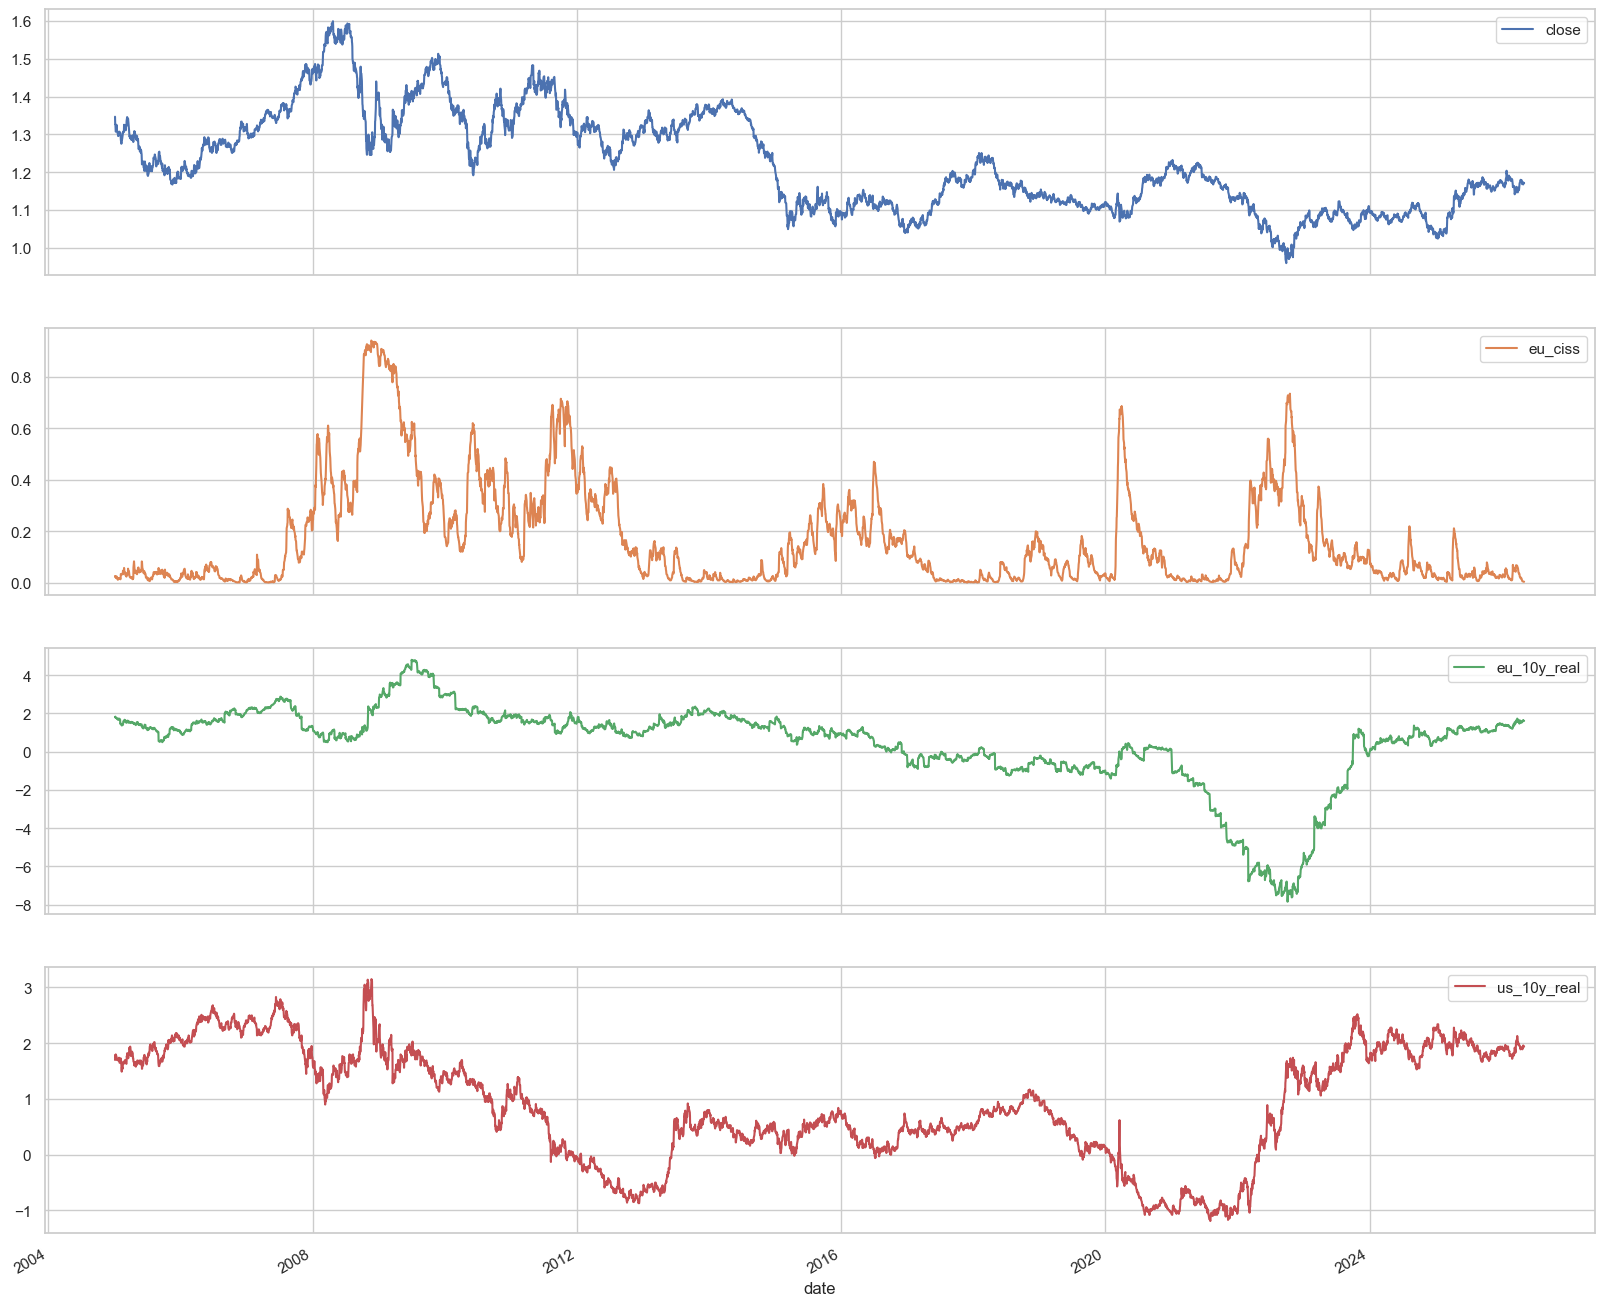

In [14]:
data[["close", "eu_ciss", "eu_10y_real", "us_10y_real"]].plot(subplots=True, figsize=(20, 18), grid=True, sharex=True)

In [8]:
data = load_research_data(DATA_PATH, date_col=DATE_COL)
if TARGET_COL not in data.columns:
    data = add_forward_return_target(data, target_col=TARGET_COL, price_col=PRICE_COL, periods=1)

validation = registry.validate(data.columns)
display(validation)

modeler = LinearFeatureModeler(
    data=data,
    target_col=TARGET_COL,
    registry=registry,
    standardize=True,
    cov_type="HAC",
    cov_kwds={"maxlags": 5},
)

runs = modeler.run_specs(REGRESSION_SPECS)
comparison = modeler.compare_runs(runs)
comparison


,group,n_features,n_missing,missing_features
0,price_action,5,0,
1,momentum_trend,21,0,
2,realized_volatility,4,0,
3,macro_rates,12,0,
4,risk_confidence,8,0,
5,positioning_flows,4,0,
6,cycles_regime,4,0,


,model,groups,nobs,n_features,r2,adj_r2,aic,bic,max_pvalue,share_p_lt_10pct,share_p_lt_05pct
0,full_mtofx,price_action+momentum_trend+realized_volatilit...,4553,58,0.024956,0.013469,-34277.684857,-33930.813609,1.000000,0.017241,0.00
1,full_mtofx_stationary,price_action+momentum_trend+realized_volatilit...,4553,48,0.021433,0.012101,-34281.265970,-33998.630138,NaN,0.000000,0.00
2,technical_core,price_action+momentum_trend+realized_volatility,5338,30,0.009727,0.004317,-40264.381284,-40066.903094,NaN,0.000000,0.00
3,realized_volatility,realized_volatility,5474,4,0.004122,0.003393,-41299.603462,-41266.564637,0.302822,0.500000,0.50
4,positioning_flows,positioning_flows,5278,4,0.001681,0.000924,-39812.077660,-39779.221147,0.588487,0.250000,0.00
5,momentum_trend,momentum_trend,5338,21,0.004518,0.000774,-40254.374835,-40116.140102,1.000000,0.000000,0.00
6,cycles_regime,cycles_regime,5537,4,0.001302,0.000580,-41759.706043,-41726.610002,0.815562,0.250000,0.25
7,price_action,price_action,5517,5,0.001073,0.000167,-41607.631074,-41567.937537,0.950102,0.000000,0.00
8,macro_rates,macro_rates,4553,12,0.002163,-0.000034,-34258.477529,-34187.818571,0.986564,0.083333,0.00
9,rates_risk_flows,macro_rates+risk_confidence+positioning_flows,4553,24,0.004079,-0.000316,-34247.230977,-34112.336603,0.979981,0.166667,0.00


In [11]:
best_model_name = comparison.iloc[0]["model"]
best_run = runs[best_model_name]

coef_table = modeler.coefficient_table(best_run)
group_tests = modeler.group_f_tests(best_run)

print(f"Best model by adjusted R^2: {best_model_name}")
display(group_tests)
display(coef_table.head(30))


Best model by adjusted R^2: full_mtofx


C:\Users\Hermes\miniconda3\envs\adonys\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 21, but rank is 1
  warnings.warn('covariance of constraints does not have full '
C:\Users\Hermes\miniconda3\envs\adonys\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 1
  warnings.warn('covariance of constraints does not have full '
C:\Users\Hermes\miniconda3\envs\adonys\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,group,n_features,f_stat,p_value
5,positioning_flows,4,1.665201e+00,0.155142
0,price_action,5,1.397573e+00,0.221775
2,realized_volatility,4,1.163315e+00,0.324915
6,cycles_regime,4,5.530237e-01,0.696825
3,macro_rates,12,3.962257e-14,1.000000
1,momentum_trend,21,3.797058e-14,1.000000
4,risk_confidence,8,3.709007e-14,1.000000


,feature,coef,std_err,t_stat,p_value,ci_low,ci_high,group
28,vol_63d,0.000400,2.905072,0.000138,0.999890,-5.693437,5.694237,realized_volatility
29,atr_14,-0.004889,42.570517,-0.000115,0.999908,-83.441569,83.431791,realized_volatility
30,atr_pct_14,0.004127,51.925624,0.000079,0.999937,-101.768225,101.776480,realized_volatility
5,range_pct,-0.000225,3.986563,-0.000056,0.999955,-7.813744,7.813294,price_action
40,ecb_main_refi_rate,0.003454,64.109333,0.000054,0.999957,-125.648530,125.655438,macro_rates
6,ret_5d,0.000052,1.026995,0.000051,0.999960,-2.012822,2.012926,momentum_trend
39,ecb_deposit_rate,-0.004037,82.374313,-0.000049,0.999961,-161.454725,161.446650,macro_rates
4,drawdown_20,0.000219,6.054913,0.000036,0.999971,-11.867192,11.867629,price_action
34,fed_funds,0.001082,30.902104,0.000035,0.999972,-60.565928,60.568093,macro_rates
53,cot_euro_net_z_156w,0.000245,9.719115,0.000025,0.999980,-19.048870,19.049361,positioning_flows


In [12]:
incremental_vs_technical = modeler.incremental_group_contribution(
    base_groups=["price_action", "momentum_trend", "realized_volatility"],
    candidate_groups=["macro_rates", "risk_confidence", "positioning_flows", "cycles_regime"],
    exclude=RAW_MA_LEVELS,
)
incremental_vs_technical


,added_group,base_adj_r2,expanded_adj_r2,delta_adj_r2,base_aic,expanded_aic,delta_aic,expanded_n_features
0,macro_rates,0.003733,0.007754,0.004021,-40271.200733,-34275.157985,5996.042748,32
2,positioning_flows,0.003733,0.004913,0.001180,-40271.200733,-39814.243043,456.957690,24
3,cycles_regime,0.003733,0.004391,0.000658,-40271.200733,-40270.744545,0.456188,24
1,risk_confidence,0.003733,0.003447,-0.000286,-40271.200733,-40263.695113,7.505620,28


## Charts

The charts below are intentionally simple: model comparison, coefficient ranking, group significance, rolling R^2, and rolling coefficient stability. Use them to identify whether explanatory power is concentrated in a few fragile variables or distributed across an economically coherent module.


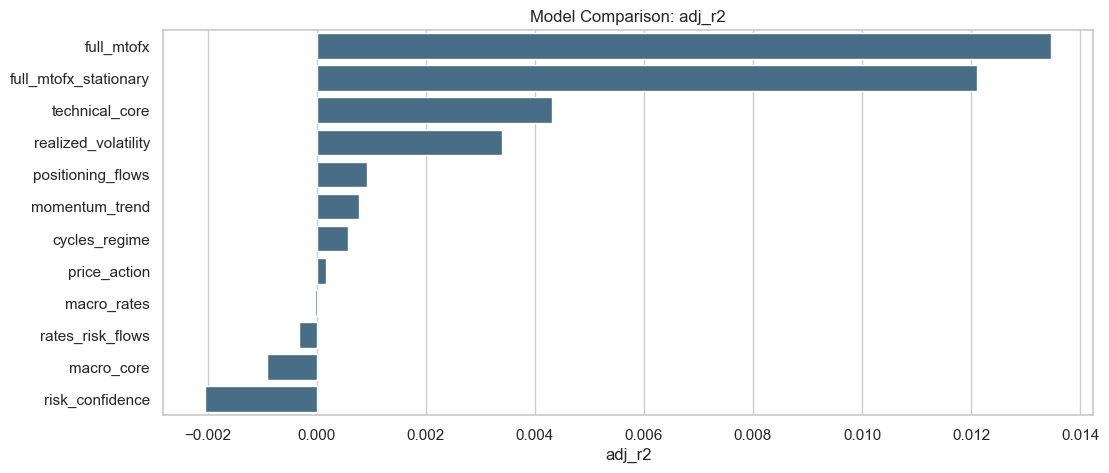

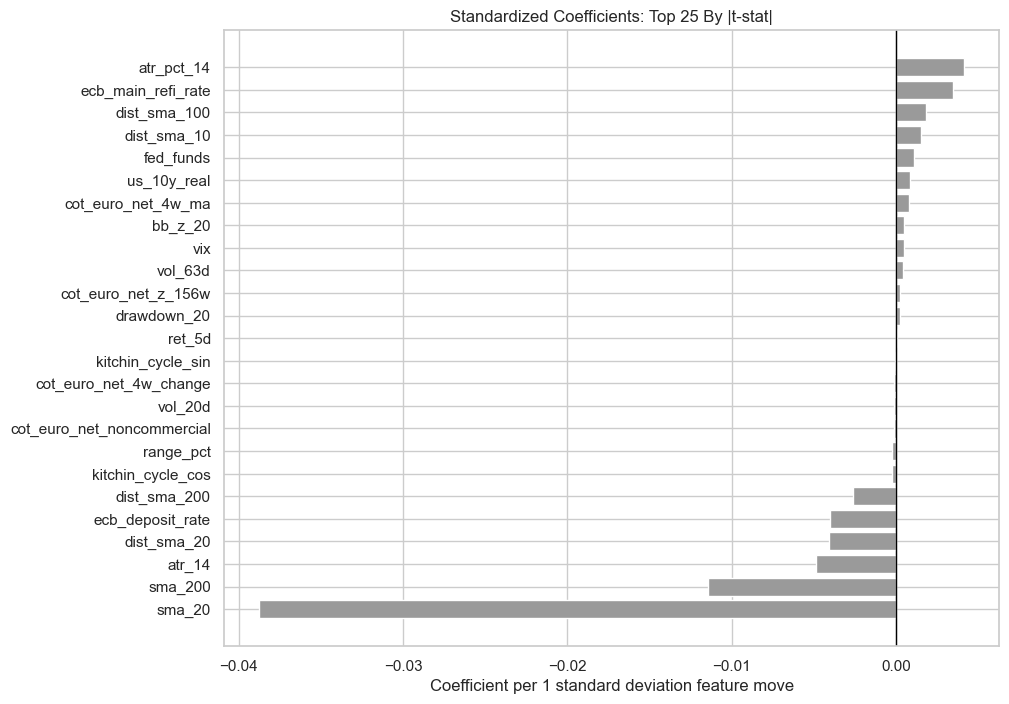

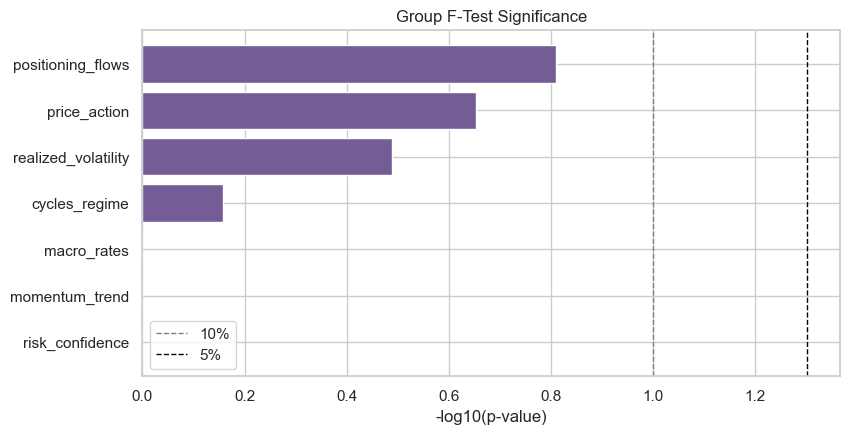

In [13]:
def plot_model_comparison(comparison: pd.DataFrame, metric: str = "adj_r2", *, top_n: int | None = None) -> plt.Axes:
    plot_df = comparison.copy()
    if top_n is not None:
        plot_df = plot_df.head(top_n)
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=plot_df, x=metric, y="model", ax=ax, color="#3d6f91")
    ax.set_title(f"Model Comparison: {metric}")
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    return ax


def plot_coefficients(coef_table: pd.DataFrame, *, top_n: int = 25, p_cutoff: float = 0.10) -> plt.Axes:
    plot_df = coef_table[coef_table["feature"] != "const"].copy()
    plot_df["abs_t"] = plot_df["t_stat"].abs()
    plot_df = plot_df.sort_values("abs_t", ascending=False).head(top_n).sort_values("coef")
    colors = np.where(plot_df["p_value"] <= p_cutoff, "#2f6f4e", "#9a9a9a")
    fig, ax = plt.subplots(figsize=(10, max(5, 0.32 * len(plot_df))))
    ax.barh(plot_df["feature"], plot_df["coef"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Standardized Coefficients: Top {top_n} By |t-stat|")
    ax.set_xlabel("Coefficient per 1 standard deviation feature move")
    ax.set_ylabel("")
    return ax


def plot_group_tests(group_tests: pd.DataFrame) -> plt.Axes:
    plot_df = group_tests.copy().sort_values("p_value", ascending=False)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.barh(plot_df["group"], -np.log10(plot_df["p_value"].clip(lower=1e-12)), color="#745c97")
    ax.axvline(-np.log10(0.10), color="gray", linestyle="--", linewidth=1, label="10%")
    ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1, label="5%")
    ax.set_title("Group F-Test Significance")
    ax.set_xlabel("-log10(p-value)")
    ax.set_ylabel("")
    ax.legend()
    return ax


plot_model_comparison(comparison, metric="adj_r2")
plt.show()

plot_coefficients(coef_table, top_n=25)
plt.show()

plot_group_tests(group_tests)
plt.show()


In [ ]:
rolling_model_name = "full_mtofx_stationary"
rolling_spec = REGRESSION_SPECS[rolling_model_name]

rolling_metrics, rolling_params, rolling_pvalues = modeler.rolling_fit(
    rolling_model_name,
    rolling_spec["groups"],
    exclude=rolling_spec.get("exclude"),
    window=252,
    step=21,
)

display(rolling_metrics.tail())


In [ ]:
def plot_rolling_r2(rolling_metrics: pd.DataFrame, metric: str = "adj_r2") -> plt.Axes:
    fig, ax = plt.subplots(figsize=(12, 4.5))
    rolling_metrics[metric].plot(ax=ax, color="#3d6f91", linewidth=2)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Rolling {metric}")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    return ax


def coefficient_stability_summary(
    rolling_params: pd.DataFrame,
    rolling_pvalues: pd.DataFrame,
    *,
    p_cutoff: float = 0.10,
) -> pd.DataFrame:
    if rolling_params.empty:
        return pd.DataFrame()
    params = rolling_params.drop(columns=["const"], errors="ignore")
    pvals = rolling_pvalues.reindex(columns=params.columns)
    rows = []
    for feature in params.columns:
        series = params[feature].dropna()
        if series.empty:
            continue
        dominant_sign = np.sign(series.mean())
        sign_consistency = (np.sign(series) == dominant_sign).mean() if dominant_sign != 0 else np.nan
        rows.append(
            {
                "feature": feature,
                "group": registry.feature_to_group().get(feature, "unknown"),
                "mean_coef": series.mean(),
                "coef_std": series.std(ddof=0),
                "sign_consistency": sign_consistency,
                "share_significant": (pvals[feature] < p_cutoff).mean() if feature in pvals else np.nan,
                "last_coef": series.iloc[-1],
            }
        )
    return pd.DataFrame(rows).sort_values(["share_significant", "sign_consistency"], ascending=False)


def plot_rolling_coefficients(
    rolling_params: pd.DataFrame,
    features: Sequence[str],
    *,
    title: str = "Rolling Standardized Coefficients",
) -> plt.Axes:
    plot_features = [feature for feature in features if feature in rolling_params.columns]
    if not plot_features:
        raise ValueError("None of the requested features are available in rolling_params.")
    fig, ax = plt.subplots(figsize=(12, 5))
    rolling_params[plot_features].plot(ax=ax, linewidth=1.8)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Coefficient")
    return ax


stability = coefficient_stability_summary(rolling_params, rolling_pvalues, p_cutoff=0.10)
display(stability.head(30))

if not rolling_metrics.empty:
    plot_rolling_r2(rolling_metrics, metric="adj_r2")
    plt.show()

stable_features = stability.head(8)["feature"].tolist() if not stability.empty else []
if stable_features:
    plot_rolling_coefficients(rolling_params, stable_features)
    plt.show()


## Economic Interpretation Template

Use the tables above to form the final interpretation:

1. Start with single-group models. A group is interesting if it has positive adjusted R^2, better AIC than similar groups, and a non-trivial share of significant coefficients.
2. Compare `technical_core` versus `macro_core`. Daily EURUSD often gives more in-sample fit to price-action and trend variables, while macro variables may be more episodic and regime-dependent.
3. Use `incremental_vs_technical` to identify which MTOFX macro module adds value after price action is already included. A useful group should increase adjusted R^2 and reduce AIC.
4. Inspect group F-tests in the best model. This asks whether the group is jointly useful after controlling for other included groups.
5. Inspect rolling R^2 and coefficient stability. Prefer groups whose coefficients keep economically sensible signs and retain significance across windows.

Typical macro reading:

- `macro_rates` adds explanatory power when USD real-rate and Fed-policy shocks dominate EURUSD. Stable signs are more important than raw p-values because rate regimes shift.
- `risk_confidence` matters when EURUSD trades as a risk/safe-haven pair. VIX stress often supports USD, but the relationship can flip when US-specific stress is the source of volatility.
- `positioning_flows` is a medium-horizon crowding block. It is strongest when COT extremes or large 4-week changes precede squeezes or trend exhaustion.
- `cycles_regime` should rarely win alone; its role is to condition the background environment and improve stability in combined models.
- `price_action`, `momentum_trend`, and `realized_volatility` are the practical timing layer. If they dominate but are unstable, the model is probably fitting local market microstructure rather than durable macro logic.


## Practical Notes For Linear EURUSD Models

- Check multicollinearity before trusting coefficient signs, especially among SMA/EMA levels, distance-to-average variables, MACD variables, and US rate variables.
- Prefer `full_mtofx_stationary` for return prediction unless you have a strong reason to include raw moving-average levels.
- Use HAC standard errors for daily overlapping/serially correlated residuals. The default here uses 5 lags.
- Keep the model simple. If a module does not improve adjusted R^2, AIC, group significance, or stability, it is not earning its degrees of freedom.
